In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Stat I project - FIFA World Cup 2026 player performance

Dataset #7, by Macéo Drouot and Axel Bachon

## Loading the data

In [11]:
df = pd.read_csv('statsbomb_world_cup_2022_player_match.csv')
df

,competition_id,season_id,match_id,match_date,match_name,stage,player_id,player_name,team_id,team_name,...,dribbles,completed_dribbles,pressures,tackles,interceptions,fouls_committed,fouls_won,total_pass_distance,total_carry_distance,expected_goals
0,43,106,3857286,2022-11-20,Qatar - Ecuador,Group Stage,12803,Romario Andrés Ibarra Mina,3565,Ecuador,...,1,1,8,0,0,0,0,170.148306,115.510117,0.136638
1,43,106,3857286,2022-11-20,Qatar - Ecuador,Group Stage,23830,Jhegson Sebastián Méndez Carabalí,3565,Ecuador,...,0,0,9,3,0,3,1,1566.175661,241.277374,0.000000
2,43,106,3857286,2022-11-20,Qatar - Ecuador,Group Stage,24085,Pervis Josué Estupiñán Tenorio,3565,Ecuador,...,1,1,7,3,1,3,0,1465.181417,243.689772,0.000000
3,43,106,3857286,2022-11-20,Qatar - Ecuador,Group Stage,28559,Enner Remberto Valencia Lastra,3565,Ecuador,...,3,2,14,0,0,1,4,264.577535,82.604804,0.872281
4,43,106,3857286,2022-11-20,Qatar - Ecuador,Group Stage,30111,Felix Eduardo Torres Caicedo,3565,Ecuador,...,1,0,4,0,1,0,0,1443.594843,231.100259,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1990,43,106,3869685,2022-12-18,Argentina - France,Final,7161,Germán Alejandro Pezzella,779,Argentina,...,0,0,0,0,0,0,0,18.220043,0.500000,0.000000
1991,43,106,3869685,2022-12-18,Argentina - France,Final,11456,Lautaro Javier Martínez,779,Argentina,...,0,0,2,0,0,0,0,62.932389,27.414423,0.583520
1992,43,106,3869685,2022-12-18,Argentina - France,Final,16308,Leandro Daniel Paredes,779,Argentina,...,0,0,5,1,0,1,0,281.049523,66.599847,0.000000
1993,43,106,3869685,2022-12-18,Argentina - France,Final,19597,Marcos Javier Acuña,779,Argentina,...,2,0,10,1,0,2,0,559.046995,139.699373,0.000000


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1995 entries, 0 to 1994
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   competition_id          1995 non-null   int64  
 1   season_id               1995 non-null   int64  
 2   match_id                1995 non-null   int64  
 3   match_date              1995 non-null   object 
 4   match_name              1995 non-null   object 
 5   stage                   1995 non-null   object 
 6   player_id               1995 non-null   int64  
 7   player_name             1995 non-null   object 
 8   team_id                 1995 non-null   int64  
 9   team_name               1995 non-null   object 
 10  opponent_id             1995 non-null   int64  
 11  opponent_name           1995 non-null   object 
 12  is_home                 1995 non-null   int64  
 13  position_id             1995 non-null   int64  
 14  position                1995 non-null   

The file has 54,600 rows and 75 columns and no missing values. One row is one player in one match. For each match the whole squad of both teams is listed (26 players each), so the players who stayed on the bench are also in the file.

23,042 rows are players who did not play (0 minutes, 0 km, 0 shots...). They don't tell us anything about performance, so we remove them and only keep the players who played.

# Template for describing data

## Population under study:

- Population: the appearances of players at the World Cup 2026 in the dataset (one player in one match, with at least 1 minute played)
- Number of observations: 31,558
- Time series (Y/N): N

In [13]:
df.nunique()

competition_id               1
season_id                    1
match_id                    64
match_date                  23
match_name                  64
stage                        6
player_id                  680
player_name                681
team_id                     32
team_name                   32
opponent_id                 32
opponent_name               32
is_home                      2
position_id                 23
position                    23
is_starter                   2
minutes_played            1195
match_duration_minutes      64
extra_time                   2
passes                     126
completed_passes           116
passes_unknown_outcome       5
carries                    107
shots                        9
shots_on_target              6
goals                        4
own_goals                    2
assists                      3
dribbles                    15
completed_dribbles          11
pressures                   37
tackles                     10
intercep

We convert total_carry_distance from yards to meters

In [18]:
total_carry_distance_m = df['total_carry_distance'] * 0.9144

In [ ]:
df[['shots', 'total_carry_distance', 'minutes_played']].describe()

KeyError: "['total_carry_distance_m'] not in index"

## Variables:

We chose 3 variables for the project:

| Name | Cat./Disc./Cont. | Obs./Exp. | levels, values or range |
|---|---|---|---|
| position | Categorical | Observed | Goalkeeper, Defender, Midfielder, Forward |
| shots | Discrete | Observed | 0 to 11 |
| total_carry_distance | Continuous | Observed | 0 to 1120.72 meters |

Some other variables of the file: minutes_played (discrete, 5 to 90), team (categorical, 48 teams), tournament_stage (categorical, 7 stages from Group Stage to Final).

## Source and quality:

- source: Kaggle (https://www.kaggle.com/datasets/rauffauzanrambe/fifa-world-cup-2026-player-performance-dataset)
- data collection method: census (all the players of all the matches)
- quality/reliability: the file is clean (no missing values), but the data seems to be fake/generated. There are 1,050 matches while the real World Cup 2026 only has 104, and some names look invented (for example Rodri Fati or Ansu Le Normand). So we use it as an exercise and not to say things about the real tournament.

## Raw/process (if not raw):

Processed: we removed the players with 0 minutes played. The values were not changed.

## Frequency tables

### position (categorical)

In [ ]:
values_pos, counts_pos = np.unique(df.position, return_counts=True)
table_pos = pd.DataFrame({'freq.': counts_pos}, index=values_pos)
table_pos['rel. freq.'] = counts_pos / n
table_pos

,freq.,rel. freq.
Defender,11484,0.363901
Forward,7700,0.243995
Goalkeeper,2100,0.066544
Midfielder,10274,0.325559


Defenders and midfielders are the most common. There are few goalkeepers because only one plays per team. No cumulated frequency because there is no order between positions.

### shots (discrete)

In [ ]:
values_s, counts_s = np.unique(df.shots, return_counts=True)
table_s = pd.DataFrame({'freq.': counts_s}, index=values_s)
table_s['rel. freq.'] = counts_s / n
table_s['cumul. rel. freq.'] = np.cumsum(table_s['rel. freq.'])
table_s

,freq.,rel. freq.,cumul. rel. freq.
0,17497,0.554439,0.554439
1,8084,0.256163,0.810603
2,3422,0.108435,0.919038
3,1484,0.047025,0.966062
4,623,0.019741,0.985804
5,263,0.008334,0.994138
6,108,0.003422,0.997560
7,53,0.001679,0.999239
8,18,0.000570,0.999810
9,3,0.000095,0.999905


55% of the players don't shoot at all in a match and 81% shoot at most once. 5 shots or more is very rare.

### distance_covered_km (continuous)

We make classes of 1 km between 2 and 14 km (every class has at least 5 units).

In [ ]:
counts_d, bins_d = np.histogram(df.distance_covered_km, bins=np.arange(2, 15, 1))
intervals = list(pd.IntervalIndex.from_breaks(bins_d, closed='left'))
intervals[-1] = pd.Interval(bins_d[-2], bins_d[-1], closed='both')  # last class is closed
table_d = pd.DataFrame({'freq.': counts_d}, index=pd.Index(intervals))
table_d['rel. freq.'] = counts_d / n
table_d['cumul. rel. freq.'] = np.cumsum(table_d['rel. freq.'])
table_d

,freq.,rel. freq.,cumul. rel. freq.
"[2, 3)",3474,0.110083,0.110083
"[3, 4)",3822,0.121110,0.231193
"[4, 5)",1243,0.039388,0.270581
"[5, 6)",1567,0.049655,0.320236
"[6, 7)",3240,0.102668,0.422904
"[7, 8)",4856,0.153875,0.576779
"[8, 9)",5240,0.166043,0.742823
"[9, 10)",4127,0.130775,0.873598
"[10, 11)",2480,0.078585,0.952183
"[11, 12)",1046,0.033145,0.985329


There are two groups: players around 2-4 km (substitutes who played a short time) and players around 7-10 km (who played the full match).

## Graphs

### position

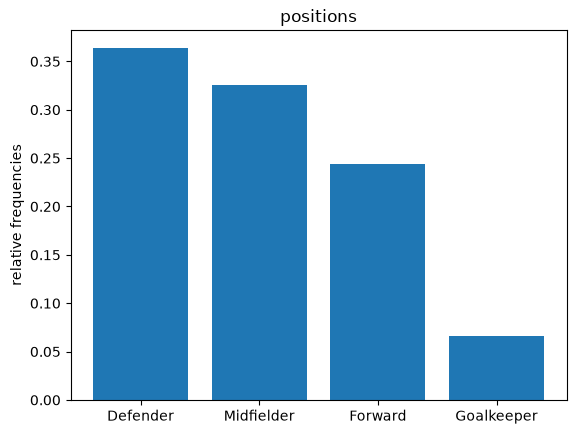

In [ ]:
counts = df.position.value_counts()
plt.bar(counts.index, counts.values / n)
plt.ylabel('relative frequencies')
plt.title('positions')
plt.show()

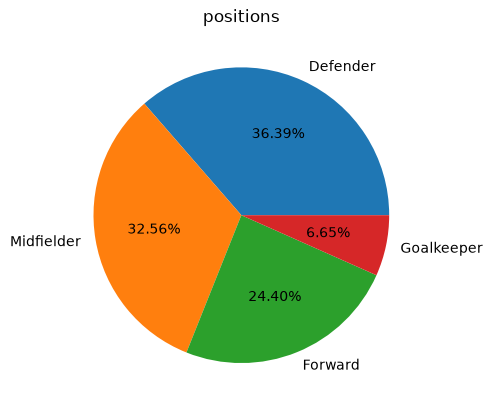

In [ ]:
plt.pie(counts.values, labels=counts.index, autopct='%.2f%%')
plt.title('positions')
plt.show()

Same result in both graphs: Defender > Midfielder > Forward > Goalkeeper.

### shots

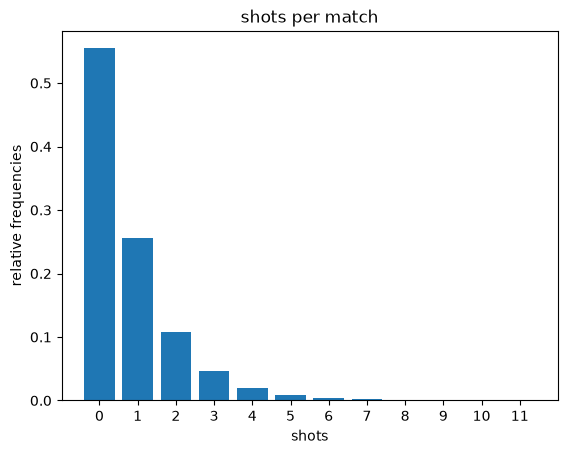

In [ ]:
plt.bar(values_s, counts_s / n)
plt.xticks(values_s, values_s)
plt.xlabel('shots')
plt.ylabel('relative frequencies')
plt.title('shots per match')
plt.show()

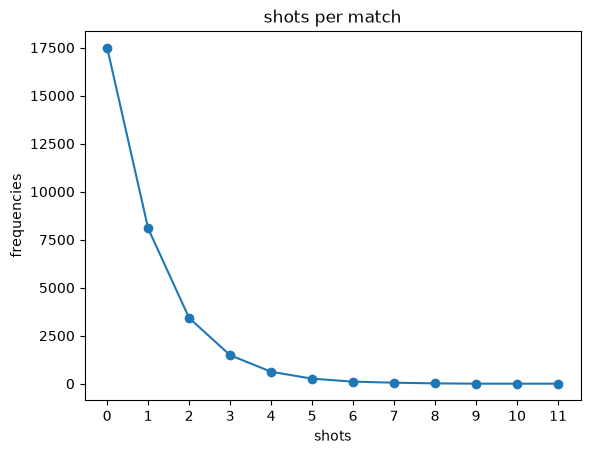

In [ ]:
plt.plot(values_s, counts_s, marker='o')
plt.xticks(values_s, values_s)
plt.xlabel('shots')
plt.ylabel('frequencies')
plt.title('shots per match')
plt.show()

The distribution is very skewed to the right: most players have 0 shots per match and the frequencies go down fast.

### distance_covered_km

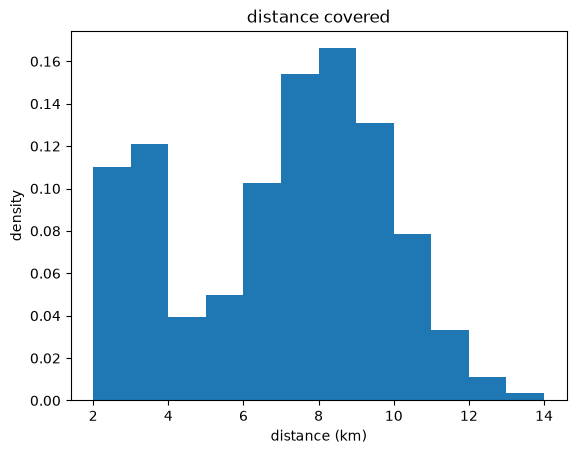

In [ ]:
plt.hist(df.distance_covered_km, bins=bins_d, density=True)
plt.xlabel('distance (km)')
plt.ylabel('density')
plt.title('distance covered')
plt.show()

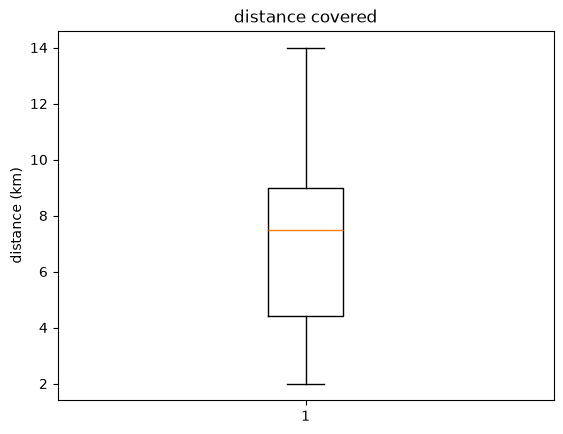

In [ ]:
plt.boxplot(df.distance_covered_km)
plt.ylabel('distance (km)')
plt.title('distance covered')
plt.show()

The histogram has two peaks (short and full matches). We can't see that on the boxplot, which only shows a median around 7.5 km and no outliers.

## Outliers

We use the 1.5 x IQR rule: a value is an outlier if it is below Q1 - 1.5 IQR or above Q3 + 1.5 IQR.

In [ ]:
for name in ['shots', 'distance_covered_km']:
    q1, q3 = np.quantile(df[name], [.25, .75], method='inverted_cdf')
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    nb_out = ((df[name] < low) | (df[name] > high)).sum()
    print(name, ': limits', low, high, '-> outliers:', nb_out)

shots : limits -1.5 2.5 -> outliers: 2555
distance_covered_km : limits -2.499999999999999 15.899999999999999 -> outliers: 0


For distance there are no outliers. For shots, Q1 = 0 and Q3 = 1, so every player with 3 shots or more is an outlier (about 8%). Let's see who they are:

In [ ]:
df[df.shots >= 3].position.value_counts() / len(df[df.shots >= 3])

position
Forward       0.728767
Midfielder    0.236791
Defender      0.034442
Name: count, dtype: float64

Most of them are forwards (73%) and midfielders (24%), so it is normal that they shoot more. These are not errors, just attacking players having a good match. So we keep them.